# Nightsky flat

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, astropy, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name==version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [17]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, ysfitsutilpy, ysphotutilpy, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is not installed... now start install")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"****** module {pkg} is installed")
    else: 
        print(f"**** module {pkg} is installed")

%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module photutils is installed
**** module ccdproc is installed
**** module ysfitsutilpy is installed
**** module ysphotutilpy is installed
**** module version_information is installed
The version_information extension is already loaded. To reload it, use:
  %reload_ext version_information
This notebook was generated at 2024-06-09 02:35:18 (KST = GMT+0900) 
0 Python     3.11.5 64bit [GCC 11.2.0]
1 IPython    8.20.0
2 OS         Linux 5.15.0 107 generic x86_64 with glibc2.31
3 numpy      1.26.4
4 pandas     2.2.1
5 matplotlib 3.8.4
6 scipy      1.12.0
7 astropy    6.1.0
8 photutils  1.9.0
9 ccdproc    2.4.2
10 ysfitsutilpy 0.2
11 ysphotutilpy 0.1.1
12 version_information 1.0.4


### import modules

In [18]:
import os
from glob import glob
from astropy.nddata import CCDData
from pathlib import Path

import ysfitsutilpy as yfu
#import ysphotutilpy as ypu
#import ysvisutilpy as yvu

import _Python_utilities
import _astro_utilities

In [19]:
#######################################################
# read all files in base directory for processing
BASEDIR = Path("/mnt/Rdata/OBS_data") 
DOINGDIR = Path(BASEDIR/ "2024-EXO" / "RiLA600_STX-16803_-_1bin")

DOINGDIRs = sorted(_Python_utilities.getFullnameListOfsubDirs(DOINGDIR))
DOINGDIRs = sorted([x for x in DOINGDIR.iterdir() if x.is_dir()])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))
#######################################################

DOINGDIRs:  [PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/-_CAL-BDF_-_2024-05_-_-_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_2024-05-23_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/TOI-1899B_LIGHT_-_2024-05-21_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/TRES-4B_LIGHT_-_2024-05-12_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/WASP-135B_LIGHT_-_2024-05-13_-_RiLA600_STX-16803_-_1bin')]
len(DOINGDIRs):  5


In [20]:
for DOINGDIR in DOINGDIRs[1:2] :
    BASEDIR = Path(BASEDIR)
    print ("Starting...\n{}".format(BASEDIR))
    fits_in_dir = sorted(list(DOINGDIR.glob('*.fit*')))
    #print("fits_in_dir", fits_in_dir)
    print("len(fits_in_dir)", len(fits_in_dir))

    if len(fits_in_dir) == 0 :
        print(f"There is no fits fils in {DOINGDIR}")
        pass
    else : 
        print(f"Starting: {str(DOINGDIR.parts[-1])}")

        MASTERDIR = DOINGDIR / _astro_utilities.master_dir
        REDUCEDDIR = DOINGDIR / _astro_utilities.reduced_dir
        REDUC_nightsky = DOINGDIR / _astro_utilities.REDUC_nightsky_dir
    
        if not REDUC_nightsky.exists():
            os.makedirs("{}".format(str(REDUC_nightsky)))
            print("{} is created...".format(str(REDUC_nightsky)))
    
        summary = yfu.make_summary(DOINGDIR/"*.fit*",
                                    keywords = ["FILTER", 'SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2',
                                        'EXTEND', 'BZERO', 'IMAGETYP', 'EXPOSURE', 'EXPTIME', 'DATE-LOC',
                                        'DATE-OBS', 'XBINNING', 'YBINNING', 'EGAIN', 'XPIXSZ', 'YPIXSZ',
                                        'INSTRUME', 'SET-TEMP', 'CCD-TEMP', 'TELESCOP', 'FOCALLEN', 'FOCRATIO',
                                        'OBJECT', 'OBJCTRA', 'OBJCTDEC', 'OBJCTROT', 'ROWORDER', 'EQUINOX',
                                        'SWCREATE', 'NOTES']
                                                )
        #print(summary)
        print("len(summary):", len(summary))
        print("summary:", summary)
        #print(summary["file"][0])   


Starting...
/mnt/Rdata/OBS_data
len(fits_in_dir) 32
Starting: KOI-13b_LIGHT_-_2024-05-23_-_RiLA600_STX-16803_-_1bin
/mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_2024-05-23_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky is created...
Extracting keys:  ['FILTER', 'SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2', 'EXTEND', 'BZERO', 'IMAGETYP', 'EXPOSURE', 'EXPTIME', 'DATE-LOC', 'DATE-OBS', 'XBINNING', 'YBINNING', 'EGAIN', 'XPIXSZ', 'YPIXSZ', 'INSTRUME', 'SET-TEMP', 'CCD-TEMP', 'TELESCOP', 'FOCALLEN', 'FOCRATIO', 'OBJECT', 'OBJCTRA', 'OBJCTDEC', 'OBJCTROT', 'ROWORDER', 'EQUINOX', 'SWCREATE', 'NOTES']


/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key NOTES not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_2024-05-23_-_RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_R_2024-05-23-12-31-00_120sec_RiLA600_STX-16803_25c_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key NOTES not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_2024-05-23_-_RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_R_2024-05-23-12-33-11_150sec_RiLA600_STX-16803_24c_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key NOTES not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_202

len(summary): 32
summary:                                                  file  filesize FILTER  \
0   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
1   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
2   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
3   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
4   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
5   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
6   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
7   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
8   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
9   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
10  /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
11  /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
12  /mnt/Rda

/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key NOTES not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_2024-05-23_-_RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_V_2024-05-23-13-37-00_150sec_RiLA600_STX-16803_21c_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key NOTES not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_2024-05-23_-_RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_V_2024-05-23-13-39-42_120sec_RiLA600_STX-16803_21c_1bin.fit, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key NOTES not found for /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803_-_1bin/KOI-13b_LIGHT_-_202

In [21]:
help(yfu.make_summary)

Help on function make_summary in module ysfitsutilpy.filemgmt:

make_summary(inputs=None, extension=None, verify_fix=False, fname_option='relative', output=None, keywords=None, example_header=None, sort_by='file', sort_map=None, fullmatch=None, flags=0, querystr=None, negate_fullmatch=False, verbose=True)
    Extracts summary from the headers of FITS files.
    
    Parameters
    ----------
    inputs : glob pattern, list-like of path-like, list-like of CCDData, `~pandas.DataFrame` convertible
        The `~glob` pattern for files (e.g., ``"2020*[012].fits"``) or list of
        files (each element must be path-like or CCDData). Although it is not a
        good idea, a mixed list of CCDData and paths to the files is also
        acceptable. If a `~pandas.DataFrame` or convertible (especially
        `~astropy.table.Table`) is given, it finds the ``"file"`` column and
        use it as the input files, make a summary table from the headers of
        those files.
        If `inputs` i

In [22]:
summary_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
summary_light = summary_light.reset_index(drop=True) 

### Light

In [23]:
# %%
for filt in ["b", "v", "r", "L", "R", "G", "B"]:
#for filt in ["V"]:
    summary_light_filt = summary_light.loc[summary_light["FILTER"] == filt].copy()
    
    if summary_light_filt.empty:
        print("The dataframe(summary_light_filt) is empty")
        pass
    else:
        try:
            print("len(summary_light_filt):", len(summary_light_filt))
            print("summary_light_filt:", summary_light_filt)

            ccd = yfu.imcombine(
                summary_light_filt["file"].tolist(), 
                combine="med",
                scale="avg", 
                scale_to_0th=False, 
                #reject="sc", 
                #sigma=2.5,
                verbose=True,
                memlimit = 2.e+10,
                )
            ccd.write(MASTERDIR / f"nightskyflat-{filt}.fits", overwrite=True)
        except Exception as err: 
            print ('Error messgae .......')
            #_Python_utilities.write_log(err_log_file, err)

The dataframe(summary_light_filt) is empty
The dataframe(summary_light_filt) is empty
The dataframe(summary_light_filt) is empty
The dataframe(summary_light_filt) is empty
len(summary_light_filt): 16
summary_light_filt:                                                  file  filesize FILTER  \
0   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
1   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
2   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
3   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
4   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
5   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
6   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
7   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
8   /mnt/Rdata/OBS_data/2024-EXO/RiLA600_STX-16803...  33560640      R   
9   /mnt/Rdata/OBS_data/2024-EXO/RiLA600

Done.
HISTORY  Loaded 16 FITS, calculated zero, scale, weights
HISTORY  ..................................(dt = 3.732 s) 2024-06-08T17:35:25.770
- Combining
-- combine = med
Done.
HISTORY  Rejection and combination done
HISTORY  ..................................(dt = 3.157 s) 2024-06-08T17:35:28.931

- Writing output FITS... Done.

2024-06-08 17:35:28.964 (TOTAL dt =  10.2 sec)
The dataframe(summary_light_filt) is empty
The dataframe(summary_light_filt) is empty


In [24]:
#n = 0
for _, row  in df_light.iterrows():
    fpath = Path(row["file"])
    print("type(fpath)", type(fpath))
    print("fpath", fpath)


NameError: name 'df_light' is not defined

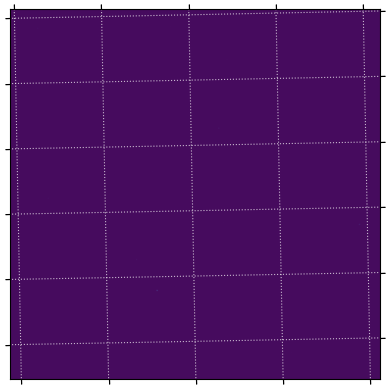

In [ ]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
 
# Open the FITS file and retrieve the data
# and WCS header keyword information from the
# first science extension. Save the WCS
# information into an Astropy WCS object.
with fits.open(str(fpath)) as hdu:
    data = hdu[0].data
    wcs = WCS(hdu[0].header)
 
# Create the plotting object with the WCS projection.
plt.subplot(projection=wcs)
plt.imshow(data, )
plt.grid(color='white', ls=':', alpha=0.7)
plt.xticks()
plt.yticks()
plt.xlabel('Right Ascension')
plt.ylabel('Declination')
 
# Save the figure.
#plt.savefig('galaxies_wcs.png')

Text(0, 0.5, 'Declination')

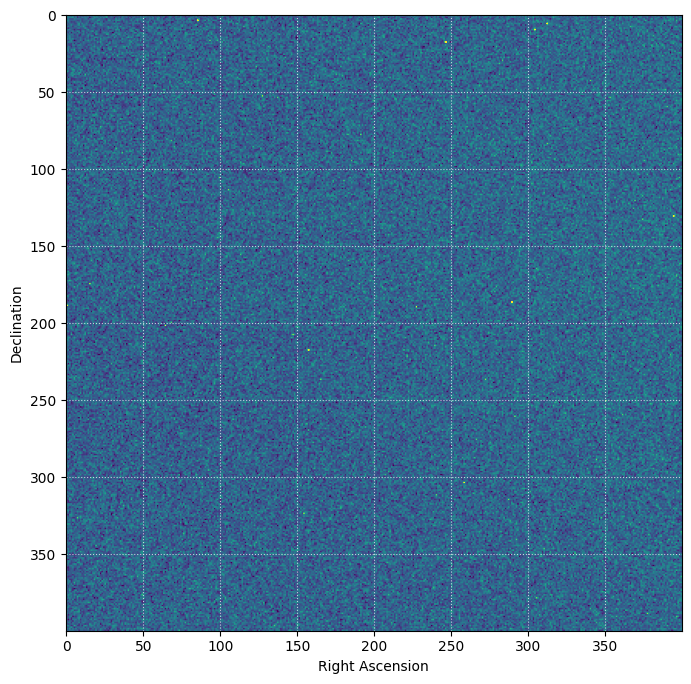

In [ ]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
 
# Open the FITS file and retrieve the data
# and WCS header keyword information from the
# first science extension. Save the WCS
# information into an Astropy WCS object.
with fits.open(str(fpath)) as hdu:
    data = hdu[0].data
    wcs = WCS(hdu[0].header)
 
# Select a subsection of the image to display.
# Here we have selected a 400 x 400 pixel section
# with x = [280:680] and y = [2290:2690].
cutout = data[2290:2690, 280:680]
 
# Create the plotting object with the WCS projection.
fig, axs = plt.subplots(1, 1, figsize=(8, 8), 
                        sharex=False, sharey=False, gridspec_kw=None)

im = yvu.zimshow(axs, 
                #hdul_dark0[0].data, 
                cutout,
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

plt.grid(color='white', ls=':', alpha=0.7)
axs.set_xlabel('Right Ascension')
axs.set_ylabel('Declination')
 
# Save the figure.
#plt.savefig('galaxies_wcs.png')

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-28-21_030sec_RiLA600_STX-16803_-30C_1bin.fit
hdu.header['OBJCTRA'] 22 06 42
wcs WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 359.750350578  3.49405302978  
CRPIX : 2058.49534607  1867.65519714  
PC1_1 PC1_2  : -3.276875618074e-06  0.0001723419227257  
PC2_1 PC2_2  : -0.0001723728549693  -3.333550886382e-06  
CDELT : 1.0  1.0  
NAXIS : 4096  4096
7  Solved in 0.3 sec. Offset 8.4'. Mount offset RA=0.8', DEC=8.3'


/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/astropy/wcs/wcs.py:3064: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


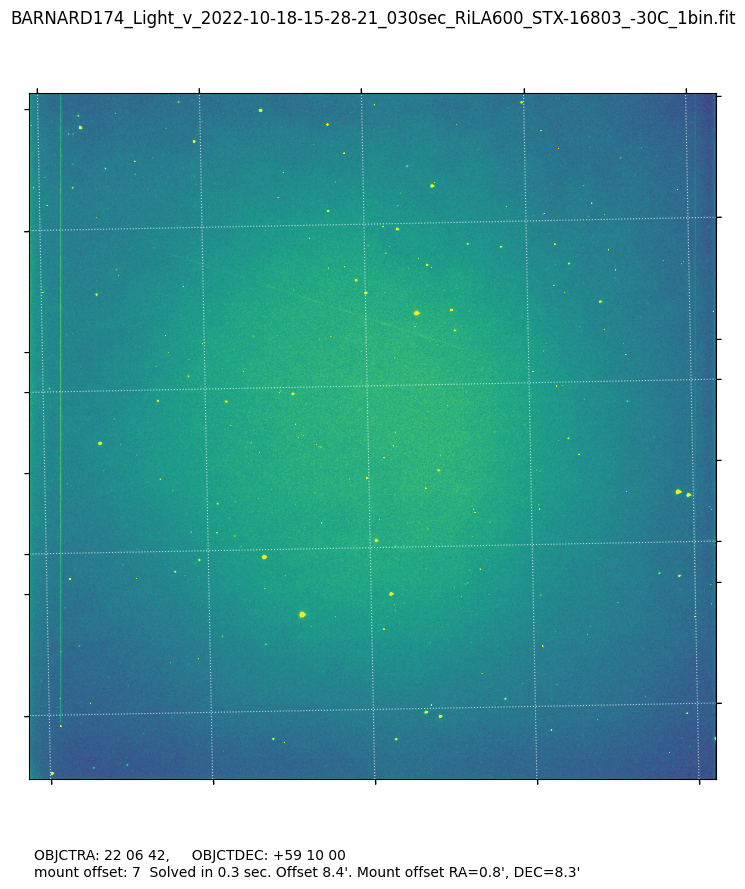

In [ ]:
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()


In [ ]:
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-22-05_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/solved/M27_Light_H_2022-10-12-13-28-39_400sec_RiLA600_STX-16803_-20C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/M34_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/M34_Light_v_2022-10-18-12-46-35_090sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/MCG2-58-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/MCG2-58-5_Light_v_2022-10-18-15-15-07_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-24-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/MCG2-58-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/MCG2-58-5_Light_v_2022-10-18-15-15-07_030sec_RiLA600_STX-16803_-30C_1bin.fit


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/Rdata/CCD_obs/RiLA600_2022/MCG2-58-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/MCG2-58-5_Light_v_2022-10-18-15-15-07_030sec_RiLA600_STX-16803_-30C_1bin.fit'

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit
hdu.header['OBJCTRA'] 05 16 26
wcs WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 78.9466382423  34.3647041165  
CRPIX : 2647.67172241  1311.15837479  
CD1_1 CD1_2  : -0.000172296100673  -1.68704459297e-06  
CD2_1 CD2_2  : 1.64351006806e-06  -0.000172421418976  
NAXIS : 4096  4096


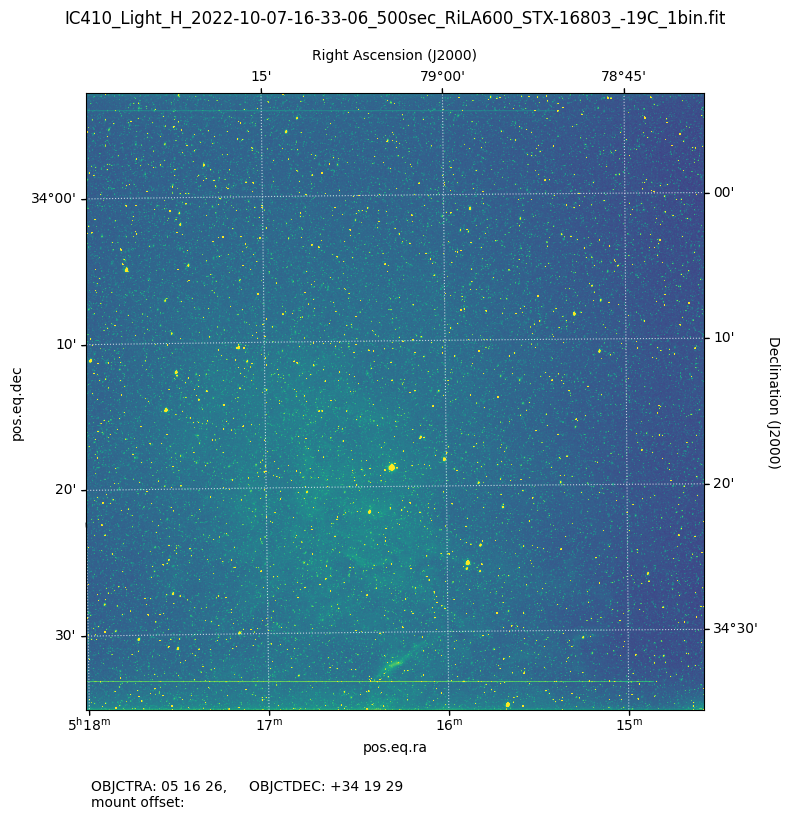

In [ ]:
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()

In [ ]:
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print(hdu.header)

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  DATE-OBS= '2022-10-07'         / ISO-8601 time of observation                   TIME-OBS= '14:13:53' /          HH:MM:SS observation start time, UT             EXPTIME =   80.000000000000000 /Exposure time in seconds                        EXPOSURE=   80.000000000000000 /Exposure time in seconds                        SET-TEMP=  -20.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -19.9687500000

In [ ]:
print(hdu.header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  DATE-OBS= '2022-10-07'         / ISO-8601 time of observation                   TIME-OBS= '14:13:53' /          HH:MM:SS observation start time, UT             EXPTIME =   80.000000000000000 /Exposure time in seconds                        EXPOSURE=   80.000000000000000 /Exposure time in seconds                        SET-TEMP=  -20.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -19.968750000000000 /CCD temperature at start of exposure in C       XPIXSZ  =   9.0000000000000000 /Pixel Width in microns (after binning)          YPIXSZ  =   9.0000000000000000 /Pixel He